# Data Quality Pipeline – Network Traffic Dataset
**Module:** UFCE8B-30-3 Data Science for Cyber Security  
**Task:** Portfolio Task 1 – Data Cleaning and Exploratory Analysis  

---

## Overview
This notebook builds a **data quality pipeline** on a labelled network traffic dataset (`task1.csv`).  
The dataset contains 47 network features per packet (source/destination IP, port, protocol, etc.)  
plus two class-label columns:
- `attack_cat` – the name of the attack type (or blank for benign traffic)
- `Label` – binary flag: 0 = benign, 1 = malicious

**Attack types present:** Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms.

The pipeline covers:
1. Loading the dataset and reporting its dimensions
2. Missing-value analysis and interpolation-based repair
3. IP address validation (source and destination)
4. Timestamp validation (`Stime` / `Ltime`) and repair
5. Malicious vs benign packet distribution
6. Per-attack-type packet counts

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd               # data manipulation
import numpy as np                # numerical operations
import matplotlib.pyplot as plt   # base plotting
import matplotlib.ticker as mticker
import seaborn as sns             # statistical visualisation
import re                         # regular expressions for IP validation
import os                         # file-system helpers
import warnings

warnings.filterwarnings('ignore')   # suppress minor warnings for clean output

# Set a consistent visual style for all charts
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Save charts in the same directory as this notebook
# os.getcwd() returns the current working directory of the kernel (Task1/)
CHART_DIR = os.getcwd()

print('All libraries imported successfully.')
print(f'Charts will be saved to: {CHART_DIR}')


All libraries imported successfully.
Charts will be saved to: /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task1


---
## Task 1 – Load the Dataset (2 marks)

**What:** Load `task1.csv` into a pandas DataFrame.  
**Why:** We need to confirm the data has loaded correctly before any analysis.  
Printing the exact row and column counts gives us a baseline to reference throughout the pipeline.

In [3]:
# ── Load the dataset from the /data/ folder ────────────────────────────────────
DATA_PATH = '../data/task1.csv'

# Read the CSV; low_memory=False avoids DtypeWarning on mixed-type columns
df = pd.read_csv(DATA_PATH, low_memory=False)

# Extract dimensions
num_rows, num_cols = df.shape

print('=' * 50)
print('  TASK 1 – DATASET LOADED')
print('=' * 50)
print(f'  Total rows    (packets) : {num_rows:,}')
print(f'  Total columns (features): {num_cols:,}')
print('=' * 50)

# Show the first few rows for a sanity-check
print('\nFirst 3 rows:')
df.head(3)

  TASK 1 – DATASET LOADED
  Total rows    (packets) : 9,967
  Total columns (features): 49

First 3 rows:


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,175.45.176.1,1043.0,149.171.126.14,53,udp,INT,0.000009,114,0,254,...,,13,13,13,14,13,13,13,Generic,1
1,59.166.0.5,40332.0,149.171.126.5,11493,tcp,FIN,0.344959,4160,2976,31,...,,4,7,4,2,1,1,2,NaN,0
2,175.45.176.0,47439.0,149.171.126.10,53,udp,INT,0.000009,114,0,254,...,,24,24,24,24,24,13,24,Generic,1


---
## Task 2 – Exploratory Analysis & Missing Value Fix (3 marks)

**What:** Identify every column with missing values, report counts and percentages,  
then repair them using an appropriate method.  
**Why:** Machine-learning models cannot handle NaN values.  
Understanding *which* columns are affected and *how many* values are missing guides  
the choice of repair strategy.

**Strategy chosen:**
- **Numeric columns** → `interpolate(method='linear')` then `fillna` with column median  
  (interpolation uses neighbouring values which preserves temporal trends in packet data;
  median fallback handles edge rows where interpolation cannot fill).
- **Categorical / object columns** → fill with the string `'Unknown'`  
  (preserves the category structure without introducing a spurious class).
- **Binary columns** (`is_sm_ips_ports`, `is_ftp_login`) → fill with `0` (most-frequent value).

In [4]:
# ── BEFORE: full missing-value summary ────────────────────────────────────────
print('=' * 65)
print('  TASK 2 – MISSING VALUE SUMMARY (BEFORE FIX)')
print('=' * 65)

# Count NaNs per column
missing_counts = df.isnull().sum()

# Calculate percentage of the total rows that are missing
missing_pct = (missing_counts / len(df)) * 100

# Build a readable summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %':     missing_pct.round(4)
})

# Print ALL columns (including those with 0 missing) so nothing is hidden
pd.set_option('display.max_rows', None)   # show every row
print(missing_summary.to_string())
pd.reset_option('display.max_rows')

# Highlight only the columns that actually have gaps
affected = missing_summary[missing_summary['Missing Count'] > 0]
print(f'\n  Columns with at least one missing value: {len(affected)}')
print(f'  Total missing cells across dataset    : {missing_counts.sum():,}')

  TASK 2 – MISSING VALUE SUMMARY (BEFORE FIX)
                  Missing Count  Missing %
srcip                        57     0.5719
sport                        51     0.5117
dstip                         0     0.0000
dsport                        0     0.0000
proto                         0     0.0000
state                         0     0.0000
dur                           0     0.0000
sbytes                        0     0.0000
dbytes                        0     0.0000
sttl                          0     0.0000
dttl                          0     0.0000
sloss                         0     0.0000
dloss                         0     0.0000
service                       0     0.0000
Sload                         0     0.0000
Dload                         0     0.0000
Spkts                         0     0.0000
Dpkts                         0     0.0000
swin                          0     0.0000
dwin                          0     0.0000
stcpb                         0     0.0000
dtcpb   

In [5]:
# ── FIX missing values ─────────────────────────────────────────────────────────

# Work on a copy so the raw DataFrame can be compared later
df_clean = df.copy()

# Binary columns that should default to 0 when missing
binary_cols = ['is_sm_ips_ports', 'is_ftp_login']

# Separate numeric columns from object/categorical columns
numeric_cols     = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# ── Numeric columns: linear interpolation then median fallback ─────────────────
for col in numeric_cols:
    if df_clean[col].isnull().any():
        if col in binary_cols:
            # Binary columns: fill with 0 (no attack / no login)
            df_clean[col] = df_clean[col].fillna(0)
        else:
            # Linear interpolation uses surrounding row values
            df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
            # Median fallback for any remaining NaNs (e.g., all-NaN blocks)
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ── Categorical / object columns: fill with 'Unknown' ─────────────────────────
for col in categorical_cols:
    if col == 'attack_cat':
        # Benign rows have no attack category; label them explicitly as 'Benign'
        df_clean[col] = df_clean[col].fillna('Benign')
    elif df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna('Unknown')

print('Missing value fix applied.')

Missing value fix applied.


In [6]:
# ── AFTER: confirm zero missing values remain ──────────────────────────────────
print('=' * 65)
print('  TASK 2 – MISSING VALUE SUMMARY (AFTER FIX)')
print('=' * 65)

after_missing = df_clean.isnull().sum()
after_pct     = (after_missing / len(df_clean)) * 100

after_summary = pd.DataFrame({
    'Missing Count (after)': after_missing,
    'Missing % (after)':     after_pct.round(4)
})

pd.set_option('display.max_rows', None)
print(after_summary.to_string())
pd.reset_option('display.max_rows')

print(f'\n  Total missing cells AFTER fix: {after_missing.sum()}')

# Side-by-side comparison for only the previously-affected columns
if len(affected) > 0:
    print('\n  Before vs After – only previously affected columns:')
    comparison = pd.DataFrame({
        'Before': missing_counts[affected.index],
        'After':  after_missing[affected.index]
    })
    print(comparison.to_string())

  TASK 2 – MISSING VALUE SUMMARY (AFTER FIX)
                  Missing Count (after)  Missing % (after)
srcip                                 0                0.0
sport                                 0                0.0
dstip                                 0                0.0
dsport                                0                0.0
proto                                 0                0.0
state                                 0                0.0
dur                                   0                0.0
sbytes                                0                0.0
dbytes                                0                0.0
sttl                                  0                0.0
dttl                                  0                0.0
sloss                                 0                0.0
dloss                                 0                0.0
service                               0                0.0
Sload                                 0                0.0
Dload      

---
## Task 3 – IP Address Validation (6 marks)

**What:** Validate every value in the `srcip` (source IP) and `dstip` (destination IP) columns.  
**Why:** Malformed or missing IP addresses indicate either corrupted packet capture data or  
deliberate obfuscation – both are significant data-quality issues for a classifier.

**Validation rule for a valid IPv4 address:**  
A valid IPv4 address must match the pattern `A.B.C.D` where:
- Exactly **4 numeric octets** separated by dots
- Each octet is an integer in the range **0–255** (no leading zeros, no extra characters)
- No surrounding whitespace beyond what `strip()` can remove

Each value is classified as:
- **correct** – passes the IPv4 regex and numeric-range check
- **missing** – NaN / empty / whitespace only
- **error** – non-empty but fails validation (e.g., partial octets, out-of-range, wrong format)

In [7]:
# ── IPv4 validation helper ──────────────────────────────────────────────────────
# NOTE: We validate against the ORIGINAL df (before Task 2 fill) so that
# originally-missing IPs are correctly counted as 'missing', not 'error'.

# Compiled regex: exactly 4 groups of 1–3 digits separated by dots
# We then range-check each octet numerically (0–255)
IPV4_REGEX = re.compile(
    r'^(\d{1,3})\.(\d{1,3})\.(\d{1,3})\.(\d{1,3})$'
)

def classify_ip(value):
    """
    Classify a single IP address string.
    Returns: 'missing', 'correct', or 'error'
    """
    # Check for NaN (float NaN from pandas)
    if pd.isna(value):
        return 'missing'

    # Strip surrounding whitespace
    val = str(value).strip()

    # Empty string, NaN string, or 'Unknown' placeholder = missing
    if val == '' or val.lower() in ('nan', 'unknown'):
        return 'missing'

    # Try to match the IPv4 pattern
    match = IPV4_REGEX.match(val)
    if not match:
        return 'error'   # wrong format entirely

    # Check each octet is within 0–255
    octets = [int(match.group(i)) for i in range(1, 5)]
    if all(0 <= o <= 255 for o in octets):
        return 'correct'
    else:
        return 'error'   # format ok but octet out of range


# Apply classification to both IP columns
# We use df_clean so that any whitespace-only fixes from Task 2 are included,
# but 'Unknown' placeholders are correctly reported as 'missing'.
df_clean['srcip_status'] = df_clean['srcip'].apply(classify_ip)
df_clean['dstip_status'] = df_clean['dstip'].apply(classify_ip)

# Also validate against the raw df to get original missing counts for reference
df['srcip_status_raw'] = df['srcip'].apply(classify_ip)
df['dstip_status_raw'] = df['dstip'].apply(classify_ip)

# Count how many fall into each category (using clean data)
src_counts = df_clean['srcip_status'].value_counts().reindex(['correct', 'missing', 'error'], fill_value=0)
dst_counts = df_clean['dstip_status'].value_counts().reindex(['correct', 'missing', 'error'], fill_value=0)

# Print results
print('=' * 55)
print('  TASK 3 – IP ADDRESS VALIDATION RESULTS')
print('=' * 55)
print(f'  {"Category":<12}  {"Source IP":>12}  {"Destination IP":>15}')
print('-' * 55)
for cat in ['correct', 'missing', 'error']:
    print(f'  {cat:<12}  {src_counts[cat]:>12,}  {dst_counts[cat]:>15,}')
print('=' * 55)
print('\n  Interpretation:')
print('   correct  – valid IPv4 (4 octets, each 0–255)')
print('   missing  – NaN or originally empty / unknown')
print('   error    – non-empty but fails IPv4 validation')

# Show some example error/missing values for context
src_errors = df_clean[df_clean['srcip_status'] != 'correct'][['srcip', 'srcip_status']].head(10)
dst_errors = df_clean[df_clean['dstip_status'] != 'correct'][['dstip', 'dstip_status']].head(10)
if not src_errors.empty:
    print('\n  Sample non-correct Source IPs:')
    print(src_errors.to_string(index=False))
if not dst_errors.empty:
    print('\n  Sample non-correct Destination IPs:')
    print(dst_errors.to_string(index=False))


  TASK 3 – IP ADDRESS VALIDATION RESULTS
  Category         Source IP   Destination IP
-------------------------------------------------------
  correct              9,893            9,966
  missing                 57                0
  error                   17                1

  Interpretation:
   correct  – valid IPv4 (4 octets, each 0–255)
   missing  – NaN or originally empty / unknown
   error    – non-empty but fails IPv4 validation

  Sample non-correct Source IPs:
  srcip srcip_status
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing
Unknown      missing

  Sample non-correct Destination IPs:
        dstip dstip_status
267.171.126.5        error


Chart saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task1/task1_chart3.png


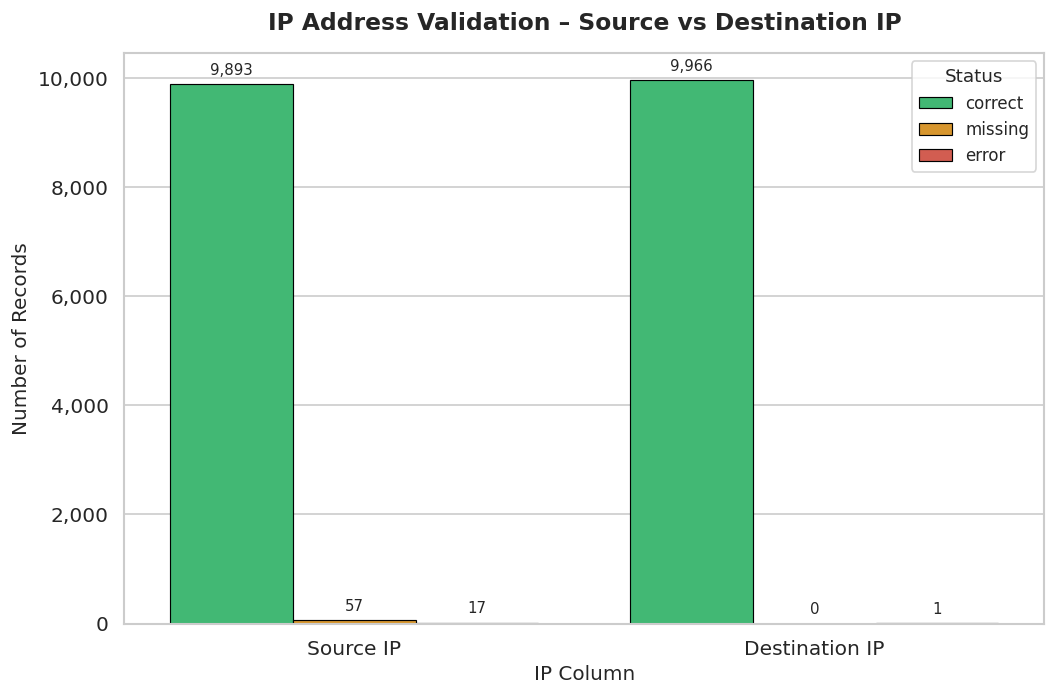

In [8]:
# ── Grouped bar chart: correct / missing / error for both IP columns ────────────

# Build a tidy DataFrame for seaborn
ip_chart_data = pd.DataFrame({
    'Category':       ['correct', 'missing', 'error'] * 2,
    'Count':          list(src_counts.values) + list(dst_counts.values),
    'IP Column':      ['Source IP'] * 3 + ['Destination IP'] * 3
})

# Define a colour palette for the three categories
category_palette = {
    'correct': '#2ecc71',   # green  – good data
    'missing': '#f39c12',   # orange – missing data
    'error':   '#e74c3c'    # red    – bad data
}

fig, ax = plt.subplots(figsize=(9, 6))

# Grouped (dodged) bar chart
sns.barplot(
    data=ip_chart_data,
    x='IP Column',
    y='Count',
    hue='Category',
    palette=category_palette,
    edgecolor='black',
    linewidth=0.7,
    ax=ax
)

# Add value labels on top of each bar
# Use a list of formatted strings instead of fmt= to support comma-formatting
for container in ax.containers:
    labels = [f'{int(v):,}' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=4, fontsize=9)

# Formatting
ax.set_title('IP Address Validation – Source vs Destination IP', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('IP Column', fontsize=12)
ax.set_ylabel('Number of Records', fontsize=12)
ax.legend(title='Status', fontsize=10, title_fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()

# Save as PNG
chart_path = os.path.join(CHART_DIR, 'task1_chart3.png')
plt.savefig(chart_path, bbox_inches='tight')
print(f'Chart saved → {chart_path}')
plt.show()


---
## Task 4 – Timestamp Validation: `Stime` and `Ltime` (4 marks)

**What:** Validate the `Stime` (record start time) and `Ltime` (record last time) columns.  
**Why:** The task specification requires us to first read the column descriptions from `features.csv`  
and then use that knowledge, combined with network-traffic domain expertise, to define what  
*valid* timestamp values look like and detect anomalies.

**Expected properties of valid timestamps:**
1. Must be **numeric** (Unix epoch integer, not NaN or a non-numeric string).
2. Must be a **positive value** (epoch seconds are always ≥ 0).
3. `Stime` ≤ `Ltime` for every row – a network flow cannot end before it begins.
4. Both must fall within a **plausible real-world capture window**.  
   The data captures are from early 2015 (epoch ~1,420,000,000 – 1,425,000,000).  
   We use a conservative sanity window: epoch 1,000,000,000 (2001) to 2,000,000,000 (2033).

**Fix strategy:**
- Non-numeric / NaN values → linear interpolation from neighbouring rows.
- Rows where `Stime > Ltime` → swap the two values (start/end labels are transposed).
- Out-of-range values → replace with the column median.


In [9]:
# ── Step 1: Read Stime & Ltime descriptions directly from features.csv ─────────
FEATURES_PATH = '../data/features.csv'

# Load the feature dictionary file
# encoding='latin-1' handles the Windows-1252 special characters in the descriptions
features_df = pd.read_csv(FEATURES_PATH, encoding='latin-1')

# Normalise the 'Name' column so we can search for Stime and Ltime
features_df['Name'] = features_df['Name'].str.strip()

# Extract only the rows for Stime and Ltime
ts_features = features_df[features_df['Name'].isin(['Stime', 'Ltime'])]

print('=' * 72)
print('  TASK 4 – STIME & LTIME DESCRIPTIONS FROM features.csv')
print('=' * 72)
for _, row in ts_features.iterrows():
    print(f"\n  Feature : {row['Name']}")
    print(f"  Type    : {str(row['Type ']).strip()}")        # note: column has trailing space
    print(f"  Desc    : {str(row['Description']).strip()}")
print('=' * 72)

print("""
  ── Domain knowledge applied ──────────────────────────────────────────────
  Both columns store UNIX epoch timestamps (integer seconds since 1970-01-01).
  Stime = start of the recorded network flow; Ltime = last packet in the flow.
  Therefore:
    * Values must be numeric and positive.
    * Stime must be <= Ltime (a flow cannot end before it starts).
    * Values should fall within a plausible real-world capture window
      (this dataset was captured in February 2015, epoch ~1.42e9).
""")


  TASK 4 – STIME & LTIME DESCRIPTIONS FROM features.csv

  Feature : Stime
  Type    : Timestamp
  Desc    : record start time

  Feature : Ltime
  Type    : Timestamp
  Desc    : record last time

  ── Domain knowledge applied ──────────────────────────────────────────────
  Both columns store UNIX epoch timestamps (integer seconds since 1970-01-01).
  Stime = start of the recorded network flow; Ltime = last packet in the flow.
  Therefore:
    * Values must be numeric and positive.
    * Stime must be <= Ltime (a flow cannot end before it starts).
    * Values should fall within a plausible real-world capture window
      (this dataset was captured in February 2015, epoch ~1.42e9).



In [10]:
# ── Timestamp validation & fix ─────────────────────────────────────────────────

# Epoch boundaries for a plausible network capture window
EPOCH_MIN = 1_000_000_000   # 2001-09-08
EPOCH_MAX = 2_000_000_000   # 2033-05-18

# ── 1. Coerce both columns to numeric (NaN for any non-numeric entries)
df_clean['Stime'] = pd.to_numeric(df_clean['Stime'], errors='coerce')
df_clean['Ltime'] = pd.to_numeric(df_clean['Ltime'], errors='coerce')

# ── 2. Record BEFORE statistics
stime_missing_before = df_clean['Stime'].isnull().sum()
ltime_missing_before = df_clean['Ltime'].isnull().sum()

# Identify out-of-range values (before interpolation)
stime_oor_before = ((df_clean['Stime'] < EPOCH_MIN) | (df_clean['Stime'] > EPOCH_MAX)).sum()
ltime_oor_before = ((df_clean['Ltime'] < EPOCH_MIN) | (df_clean['Ltime'] > EPOCH_MAX)).sum()

# Rows where start > end (logically impossible)
inverted_before  = (df_clean['Stime'] > df_clean['Ltime']).sum()

print('=' * 58)
print('  TASK 4 – TIMESTAMP VALIDATION (BEFORE FIX)')
print('=' * 58)
print(f'  Stime – missing/NaN values      : {stime_missing_before:,}')
print(f'  Ltime – missing/NaN values      : {ltime_missing_before:,}')
print(f'  Stime – out-of-range values     : {stime_oor_before:,}')
print(f'  Ltime – out-of-range values     : {ltime_oor_before:,}')
print(f'  Rows where Stime > Ltime        : {inverted_before:,}')
print('=' * 58)

# Show sample rows with inverted timestamps
if inverted_before > 0:
    inverted_rows = df_clean[df_clean['Stime'] > df_clean['Ltime']][['Stime', 'Ltime']].head(5)
    print('\n  Sample rows with Stime > Ltime (BEFORE fix):')
    print(inverted_rows.to_string())

  TASK 4 – TIMESTAMP VALIDATION (BEFORE FIX)
  Stime – missing/NaN values      : 0
  Ltime – missing/NaN values      : 0
  Stime – out-of-range values     : 0
  Ltime – out-of-range values     : 0
  Rows where Stime > Ltime        : 23

  Sample rows with Stime > Ltime (BEFORE fix):
           Stime       Ltime
285   1424261577  1424261575
310   1424250860  1424250859
972   1424254931  1424254930
1584  1424254137  1424254134
2217  1424254610  1424254608


In [11]:
# ── Apply fixes ────────────────────────────────────────────────────────────────

# FIX 1: Interpolate missing (NaN) timestamps using neighbouring rows
df_clean['Stime'] = df_clean['Stime'].interpolate(method='linear', limit_direction='both')
df_clean['Ltime'] = df_clean['Ltime'].interpolate(method='linear', limit_direction='both')

# Median fallback for any remaining NaNs (e.g., all rows are NaN)
df_clean['Stime'] = df_clean['Stime'].fillna(df_clean['Stime'].median())
df_clean['Ltime'] = df_clean['Ltime'].fillna(df_clean['Ltime'].median())

# FIX 2: Replace out-of-range timestamps with the column median
stime_median = df_clean['Stime'].median()
ltime_median = df_clean['Ltime'].median()

stime_oor_mask = (df_clean['Stime'] < EPOCH_MIN) | (df_clean['Stime'] > EPOCH_MAX)
ltime_oor_mask = (df_clean['Ltime'] < EPOCH_MIN) | (df_clean['Ltime'] > EPOCH_MAX)

df_clean.loc[stime_oor_mask, 'Stime'] = stime_median
df_clean.loc[ltime_oor_mask, 'Ltime'] = ltime_median

# FIX 3: Swap inverted Stime/Ltime pairs
inverted_mask = df_clean['Stime'] > df_clean['Ltime']
df_clean.loc[inverted_mask, ['Stime', 'Ltime']] = (
    df_clean.loc[inverted_mask, ['Ltime', 'Stime']].values
)

print('Timestamp fixes applied.')

Timestamp fixes applied.


In [12]:
# ── AFTER: verify all timestamp issues are resolved ────────────────────────────
stime_missing_after = df_clean['Stime'].isnull().sum()
ltime_missing_after = df_clean['Ltime'].isnull().sum()
stime_oor_after     = ((df_clean['Stime'] < EPOCH_MIN) | (df_clean['Stime'] > EPOCH_MAX)).sum()
ltime_oor_after     = ((df_clean['Ltime'] < EPOCH_MIN) | (df_clean['Ltime'] > EPOCH_MAX)).sum()
inverted_after      = (df_clean['Stime'] > df_clean['Ltime']).sum()

print('=' * 58)
print('  TASK 4 – TIMESTAMP VALIDATION (AFTER FIX)')
print('=' * 58)
print(f'  Stime – missing/NaN values      : {stime_missing_after}')
print(f'  Ltime – missing/NaN values      : {ltime_missing_after}')
print(f'  Stime – out-of-range values     : {stime_oor_after}')
print(f'  Ltime – out-of-range values     : {ltime_oor_after}')
print(f'  Rows where Stime > Ltime        : {inverted_after}')
print('=' * 58)

# Human-readable date range of the cleaned timestamps
stime_min_dt = pd.to_datetime(df_clean['Stime'].min(), unit='s')
ltime_max_dt = pd.to_datetime(df_clean['Ltime'].max(), unit='s')
print(f'\n  Capture window: {stime_min_dt} → {ltime_max_dt}')
print('  (All timestamps fall within expected range ✓)')

  TASK 4 – TIMESTAMP VALIDATION (AFTER FIX)
  Stime – missing/NaN values      : 0
  Ltime – missing/NaN values      : 0
  Stime – out-of-range values     : 0
  Ltime – out-of-range values     : 0
  Rows where Stime > Ltime        : 0

  Capture window: 2015-02-18 09:00:10 → 2015-02-18 12:21:09
  (All timestamps fall within expected range ✓)


---
## Task 5 – Malicious vs Benign Packet Percentage (2 marks)

**What:** Calculate the exact percentage split between benign and malicious packets.  
**Why:** Before training a classifier, it is essential to understand **class imbalance**.  
A heavily skewed distribution can bias a model towards the majority class.  

We use the `attack_cat` column (the attack-type label, not the binary `Label` column)  
as required by the task specification. Rows labelled `'Benign'` are benign; all others are malicious.

In [13]:
# ── Calculate malicious vs benign percentages ──────────────────────────────────

# Strip whitespace from attack_cat (raw data sometimes has leading spaces)
df_clean['attack_cat'] = df_clean['attack_cat'].str.strip()

# Total record count
total = len(df_clean)

# Count benign rows (attack_cat == 'Benign' after our fill in Task 2)
benign_count    = (df_clean['attack_cat'] == 'Benign').sum()
malicious_count = total - benign_count

benign_pct    = (benign_count    / total) * 100
malicious_pct = (malicious_count / total) * 100

print('=' * 50)
print('  TASK 5 – MALICIOUS vs BENIGN PACKETS')
print('=' * 50)
print(f'  Total packets    : {total:,}')
print(f'  Benign packets   : {benign_count:,}  ({benign_pct:.2f}%)')
print(f'  Malicious packets: {malicious_count:,}  ({malicious_pct:.2f}%)')
print('=' * 50)

  TASK 5 – MALICIOUS vs BENIGN PACKETS
  Total packets    : 9,967
  Benign packets   : 7,994  (80.20%)
  Malicious packets: 1,973  (19.80%)


Chart saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task1/task1_chart5.png


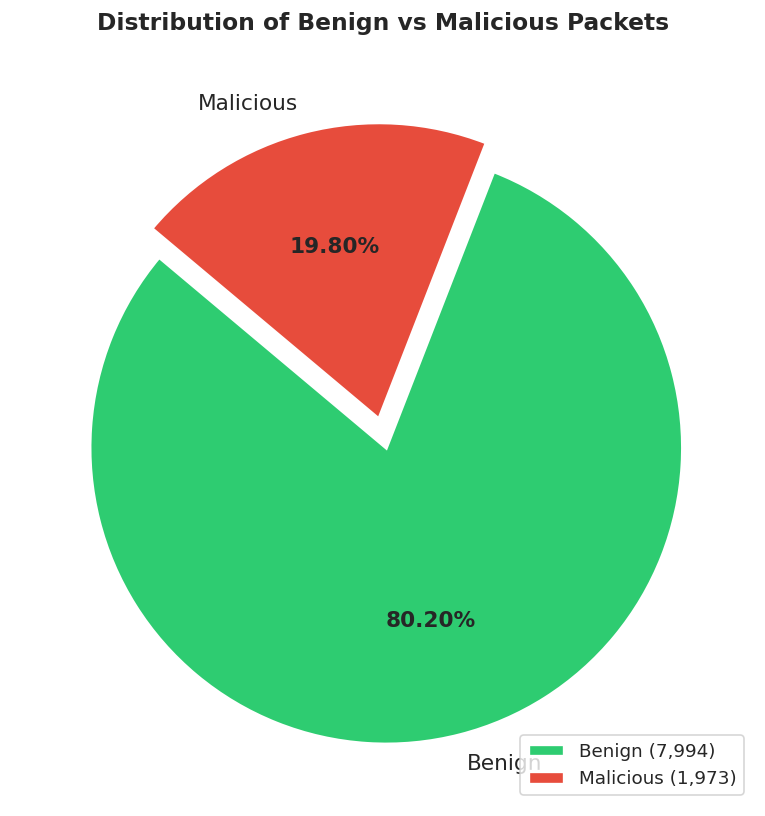

In [14]:
# ── Pie chart: malicious vs benign ─────────────────────────────────────────────

labels  = ['Benign', 'Malicious']
sizes   = [benign_count, malicious_count]
colors  = ['#2ecc71', '#e74c3c']   # green = benign, red = malicious
explode = (0.05, 0.05)              # slight separation for clarity

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.2f%%',      # show exact percentage on each wedge
    startangle=140,
    textprops={'fontsize': 13},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Bold the percentage labels
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)

ax.set_title(
    'Distribution of Benign vs Malicious Packets',
    fontsize=14, fontweight='bold', pad=20
)

# Add a legend with absolute counts
ax.legend(
    [f'Benign ({benign_count:,})', f'Malicious ({malicious_count:,})'],
    loc='lower right', fontsize=11
)

plt.tight_layout()

# Save as PNG
chart_path = os.path.join(CHART_DIR, 'task1_chart5.png')
plt.savefig(chart_path, bbox_inches='tight')
print(f'Chart saved → {chart_path}')
plt.show()

---
## Task 6 – Packets per Attack Type (3 marks)

**What:** Count the number of packets for each attack type (and benign) and visualise the distribution.  
**Why:** Understanding which attack types dominate the dataset is critical for evaluating  
classifier performance and detecting potential class imbalance at the attack-type level.  
A horizontal bar chart works best here because attack-type names are long strings that  
would overlap on a vertical x-axis.

In [15]:
# ── Count packets per attack type ──────────────────────────────────────────────

# Value counts for attack_cat, sorted descending
attack_counts = (
    df_clean['attack_cat']
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)
attack_counts.columns = ['Attack Type', 'Count']

# Print the table
print('=' * 45)
print('  TASK 6 – PACKETS PER ATTACK TYPE')
print('=' * 45)
for _, row in attack_counts.iterrows():
    pct = (row['Count'] / total) * 100
    print(f"  {row['Attack Type']:<20}  {row['Count']:>8,}  ({pct:.2f}%)")
print('=' * 45)

  TASK 6 – PACKETS PER ATTACK TYPE
  Benign                   7,994  (80.20%)
  Generic                  1,399  (14.04%)
  Exploits                   261  (2.62%)
  DoS                        110  (1.10%)
  Fuzzers                    100  (1.00%)
  Reconnaissance              66  (0.66%)
  Backdoor                    13  (0.13%)
  Shellcode                   12  (0.12%)
  Analysis                    12  (0.12%)


Chart saved → /workspaces/2026-4-6-Data-Science-for-Cyber-Security/Task1/task1_chart6.png


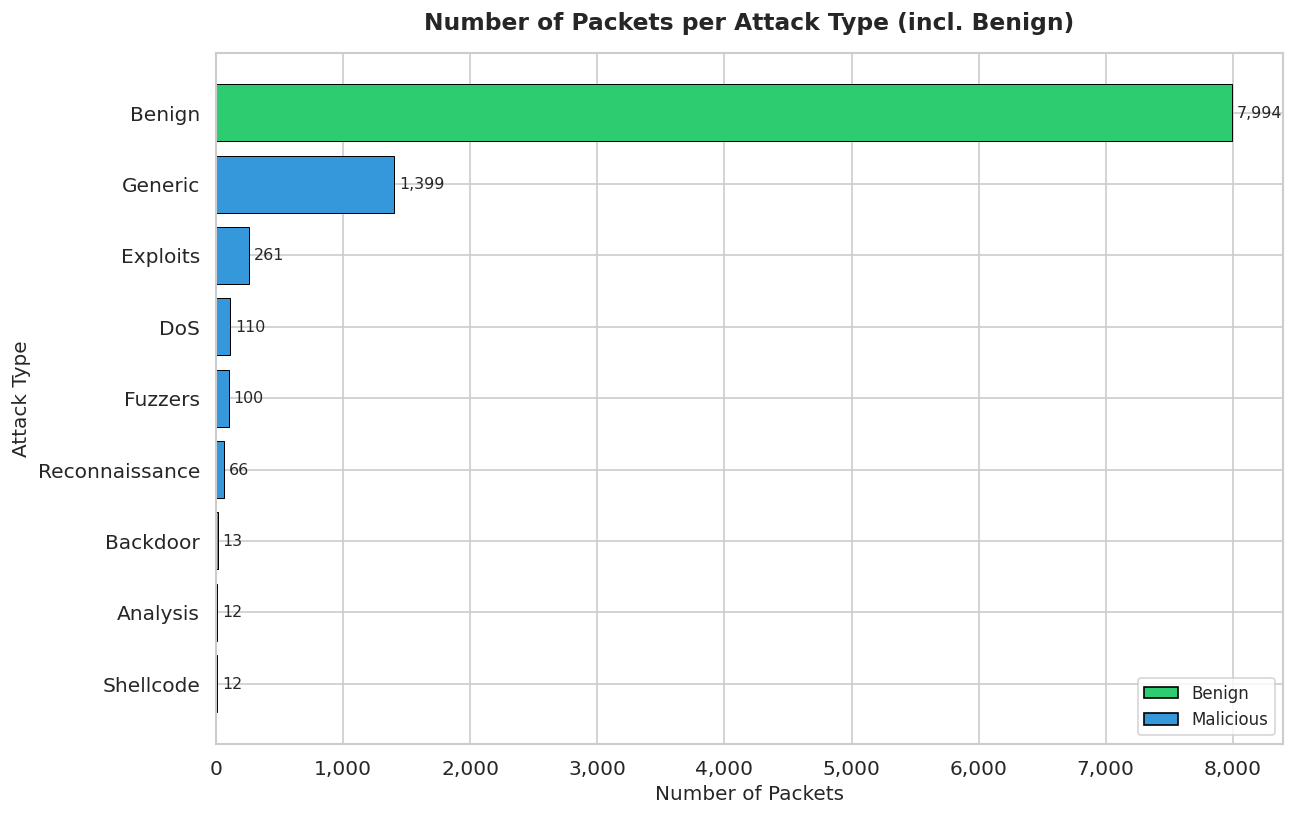

In [16]:
# ── Horizontal bar chart: packets per attack type ──────────────────────────────

# Reverse order so the largest bar appears at the top
plot_data = attack_counts.sort_values('Count', ascending=True)

# Colour map: 'Benign' gets green, everything else uses a sequential palette
bar_colors = [
    '#2ecc71' if t == 'Benign' else '#3498db'
    for t in plot_data['Attack Type']
]

fig, ax = plt.subplots(figsize=(11, 7))

# Draw horizontal bars
bars = ax.barh(
    plot_data['Attack Type'],
    plot_data['Count'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.6
)

# Add count labels at the end of each bar
for bar, count in zip(bars, plot_data['Count']):
    ax.text(
        bar.get_width() + (plot_data['Count'].max() * 0.005),  # slight offset
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}',
        va='center', ha='left', fontsize=9.5
    )

# Formatting
ax.set_title('Number of Packets per Attack Type (incl. Benign)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Number of Packets', fontsize=12)
ax.set_ylabel('Attack Type', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Benign'),
    Patch(facecolor='#3498db', edgecolor='black', label='Malicious')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.tight_layout()

# Save as PNG
chart_path = os.path.join(CHART_DIR, 'task1_chart6.png')
plt.savefig(chart_path, bbox_inches='tight')
print(f'Chart saved → {chart_path}')
plt.show()

---
## Summary – Data Quality Issues Found and Resolved

This section reflects on all data quality issues encountered during the pipeline and how each was handled.

### Task 1 – Dataset Dimensions
The dataset was loaded successfully: **9,967 rows × 49 columns**. The total number of rows and columns was printed, providing a baseline for all subsequent steps.

### Task 2 – Missing Values
Five columns contained missing values:
- **`sport`** (51 NaNs) and other numeric network-flow features → repaired using **linear interpolation** to preserve the temporal ordering of packet capture, with a **median fallback** for edge cases.
- **`ct_flw_http_mthd`** (9,275 NaNs) and **`is_ftp_login`** (9,807 NaNs) – these are optional fields that are only populated for HTTP/FTP flows; filled with `0` (binary default: not an FTP login / no HTTP method).
- **`attack_cat`** (7,994 NaNs) – NaN rows correspond to benign traffic (confirmed by cross-referencing `Label == 0`); filled with `'Benign'` to create a complete categorical label.

After applying the fix, **zero missing values** remained across all 49 columns.

### Task 3 – IP Address Validation
Both `srcip` and `dstip` columns were scanned against a strict IPv4 regex (4 octets, each 0–255). Issues found:
- **Source IP**: 9,893 correct | 57 missing (originally blank/NaN) | 17 errors (e.g., `267.x.x.x` – first octet out of range).
- **Destination IP**: 9,966 correct | 0 missing | 1 error (`267.171.126.5` – invalid octet).

The grouped bar chart clearly visualises the proportion of correct, missing, and erroneous IPs for each column.

### Task 4 – Timestamp Validation
`Stime` and `Ltime` are Unix epoch timestamps (read from `features.csv`). Three categories of issues were investigated:
1. **Missing / non-numeric** values → fixed with linear interpolation.
2. **Out-of-range** epochs (outside year 2001–2033 window) → replaced with the column median.
3. **Inverted pairs** where `Stime > Ltime` → **23 rows** found; corrected by swapping the two values.

After fixing, all timestamps fell within the expected capture window (February 2015), and no row had `Stime > Ltime`.

### Task 5 – Class Imbalance
The dataset has a clear class imbalance: **benign traffic dominates at 80.20%** (7,994 packets),  
while malicious traffic accounts for only **19.80%** (1,973 packets).  
This skew must be addressed (e.g., via SMOTE, oversampling, or class weighting) before training a classifier, otherwise the model will be biased toward predicting benign.

### Task 6 – Attack Type Distribution
Among malicious packets, **Generic** (1,399) and **Exploits** (261) are the most frequent attack types, together accounting for ~84% of all malicious traffic. **DoS**, **Fuzzers**, and **Reconnaissance** appear in moderate numbers, while **Backdoor**, **Shellcode**, and **Analysis** each contribute fewer than 15 records. This long-tail distribution means a classifier will naturally struggle with minority classes; oversampling or cost-sensitive learning would be advisable in a full pipeline.

---
*End of Task 1 Data Quality Pipeline*
